## **Social Network Analysis with R**

### Objective

The objective of this experiment is to perform Social Network Analysis (SNA) using R.
The analysis represents entities as nodes and relationships between them as edges.

The experiment includes:

- Creating and preparing network data
- Representing entities using nodes and relationships using edges
- Constructing a social network graph
- Visualizing the network
- Calculating important network measures
- Identifying highly connected and influential nodes
- Interpreting the structure and characteristics of the network

In [1]:
# Installing packages
install.packages("igraph")
install.packages("ggraph")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘tweenr’, ‘polyclip’, ‘gridExtra’, ‘RcppArmadillo’, ‘ggforce’, ‘ggrepel’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(igraph)
library(ggraph)
library(ggplot2)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2



In [3]:
# Load Zachary Karate Club network
karate <- make_graph("Zachary")

In [4]:
# Display basic information about the network
karate

IGRAPH 4fce387 U--- 34 78 -- Zachary
+ attr: name (g/c)
+ edges from 4fce387:
 [1]  1-- 2  1-- 3  1-- 4  1-- 5  1-- 6  1-- 7  1-- 8  1-- 9  1--11  1--12
[11]  1--13  1--14  1--18  1--20  1--22  1--32  2-- 3  2-- 4  2-- 8  2--14
[21]  2--18  2--20  2--22  2--31  3-- 4  3-- 8  3--28  3--29  3--33  3--10
[31]  3-- 9  3--14  4-- 8  4--13  4--14  5-- 7  5--11  6-- 7  6--11  6--17
[41]  7--17  9--31  9--33  9--34 10--34 14--34 15--33 15--34 16--33 16--34
[51] 19--33 19--34 20--34 21--33 21--34 23--33 23--34 24--26 24--28 24--33
[61] 24--34 24--30 25--26 25--28 25--32 26--32 27--30 27--34 28--34 29--32
[71] 29--34 30--33 30--34 31--33 31--34 32--33 32--34 33--34

In [5]:
# Number of nodes
vcount(karate)

# Number of edges
ecount(karate)

[1] 34

[1] 78

### Nodes and Edges

In a social network:

- Nodes (vertices) represent individuals or entities.
- Edges represent relationships or interactions between individuals.

The network can therefore be represented mathematically as:

**G = (V, E)**

where V represents the set of nodes and E represents the set of edges.

In [6]:
# Display all vertices
V(karate)

# Display all edges
E(karate)

+ 34/34 vertices, from 4fce387:
 [1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34

+ 78/78 edges from 4fce387:
 [1]  1-- 2  1-- 3  1-- 4  1-- 5  1-- 6  1-- 7  1-- 8  1-- 9  1--11  1--12
[11]  1--13  1--14  1--18  1--20  1--22  1--32  2-- 3  2-- 4  2-- 8  2--14
[21]  2--18  2--20  2--22  2--31  3-- 4  3-- 8  3--28  3--29  3--33  3--10
[31]  3-- 9  3--14  4-- 8  4--13  4--14  5-- 7  5--11  6-- 7  6--11  6--17
[41]  7--17  9--31  9--33  9--34 10--34 14--34 15--33 15--34 16--33 16--34
[51] 19--33 19--34 20--34 21--33 21--34 23--33 23--34 24--26 24--28 24--33
[61] 24--34 24--30 25--26 25--28 25--32 26--32 27--30 27--34 28--34 29--32
[71] 29--34 30--33 30--34 31--33 31--34 32--33 32--34 33--34

In [7]:
# Convert network into an edge list
edge_list <- as_edgelist(karate)

# Display first 10 relationships
head(edge_list, 10)

1,2
1,3
1,4
1,5
1,6
1,7
1,8
1,9
1,11
1,12


### Basic Network Characteristics

Before identifying influential nodes, we examine some basic properties
of the network such as the number of nodes, number of relationships,
density, and whether the network is connected.

In [8]:
# Number of nodes
nodes <- vcount(karate)

# Number of edges
edges <- ecount(karate)

# Network density
density <- edge_density(karate)

# Number of connected components
components_count <- components(karate)$no

# Display results
cat("Number of Nodes:", nodes, "\n")
cat("Number of Edges:", edges, "\n")
cat("Network Density:", round(density, 4), "\n")
cat("Connected Components:", components_count, "\n")

Number of Nodes: 34 
Number of Edges: 78 
Network Density: 0.139 
Connected Components: 1 


### Degree Centrality

Degree centrality measures the number of direct connections of each node.

A node with a high degree has relationships with many other nodes.
Therefore, high-degree nodes can be considered highly connected members
of the social network.

In [9]:
# Calculate degree centrality
degree_centrality <- degree(karate)

# Display degree values
degree_centrality

[1] 16  9 10  6  3  4  4  4  5  2  3  1  2  5  2  2  2  2  2  3  2  2  2  5  3
[26]  3  2  4  3  4  4  6 12 17

### Finidng the most connected nodes

In [10]:
# Sort nodes according to degree
degree_rank <- sort(degree_centrality, decreasing = TRUE)

# Display top 10 nodes
head(degree_rank, 10)

[1] 17 16 12 10  9  6  6  5  5  5

### Betweenness Centrality

Betweenness centrality measures how frequently a node lies on the shortest
paths between other nodes.

A node with high betweenness can act as a bridge between different groups
within the network.

Therefore, such nodes can be important for communication and information
flow.

In [11]:
# Calculate betweenness centrality
betweenness_centrality <- betweenness(karate, normalized = TRUE)

# Display results
betweenness_centrality

[1] 0.4376352814 0.0539366883 0.1436568062 0.0119092713 0.0006313131
 [6] 0.0299873737 0.0299873737 0.0000000000 0.0559268278 0.0008477633
[11] 0.0006313131 0.0000000000 0.0000000000 0.0458633959 0.0000000000
[16] 0.0000000000 0.0000000000 0.0000000000 0.0000000000 0.0324750481
[21] 0.0000000000 0.0000000000 0.0000000000 0.0176136364 0.0022095960
[26] 0.0038404882 0.0000000000 0.0223334536 0.0017947330 0.0029220779
[31] 0.0144119769 0.1382756133 0.1452471140 0.3040749759

### Identifying imp bridge nodes

In [12]:
# Sort nodes according to betweenness
betweenness_rank <- sort(
  betweenness_centrality,
  decreasing = TRUE
)

# Display top 10
head(betweenness_rank, 10)

[1] 0.43763528 0.30407498 0.14524711 0.14365681 0.13827561 0.05592683
 [7] 0.05393669 0.04586340 0.03247505 0.02998737

### Closeness Centrality

Closeness centrality measures how close a node is to all other nodes
in the network.

A node with high closeness can reach other nodes through relatively
short paths and may therefore be well positioned for spreading
information through the network.

In [13]:
# Calculate closeness centrality
closeness_centrality <- closeness(
  karate,
  normalized = TRUE
)

# Display results
closeness_centrality

[1] 0.5689655 0.4852941 0.5593220 0.4647887 0.3793103 0.3837209 0.3837209
 [8] 0.4400000 0.5156250 0.4342105 0.3793103 0.3666667 0.3707865 0.5156250
[15] 0.3707865 0.3707865 0.2844828 0.3750000 0.3707865 0.5000000 0.3707865
[22] 0.3750000 0.3707865 0.3928571 0.3750000 0.3750000 0.3626374 0.4583333
[29] 0.4520548 0.3837209 0.4583333 0.5409836 0.5156250 0.5500000

### Ranking nodes by closeness

In [14]:
closeness_rank <- sort(
  closeness_centrality,
  decreasing = TRUE
)

head(closeness_rank, 10)

[1] 0.5689655 0.5593220 0.5500000 0.5409836 0.5156250 0.5156250 0.5156250
 [8] 0.5000000 0.4852941 0.4647887

### Eigenvector Centrality

Eigenvector centrality considers not only how many connections a node has,
but also how important its connected neighbors are.

A node connected to several influential nodes can therefore receive
a high eigenvector centrality score.

In [15]:
# Calculate eigenvector centrality
eigenvector_centrality <- eigen_centrality(
  karate
)$vector

# Display results
eigenvector_centrality

[1] 0.95213237 0.71233514 0.84955420 0.56561431 0.20347148 0.21288383
 [7] 0.21288383 0.45789093 0.60906844 0.27499812 0.20347148 0.14156633
[13] 0.22566382 0.60657439 0.27159396 0.27159396 0.06330461 0.24747879
[19] 0.27159396 0.39616224 0.27159396 0.24747879 0.27159396 0.40207086
[25] 0.15280670 0.15857597 0.20242852 0.35749923 0.35107297 0.36147301
[31] 0.46806481 0.51165649 0.82665886 1.00000000

### Compare Centrality Measures

In [16]:
centrality_table <- data.frame(
  Node = V(karate),
  Degree = degree_centrality,
  Betweenness = betweenness_centrality,
  Closeness = closeness_centrality,
  Eigenvector = eigenvector_centrality
)

# Sort according to degree
centrality_table <- centrality_table[
  order(-centrality_table$Degree),
]

# Display top 10
head(centrality_table, 10)

,Node,Degree,Betweenness,Closeness,Eigenvector
,<igrph.vs>,<dbl>,<dbl>,<dbl>,<dbl>
34,34,17,0.30407498,0.5500000,1.0000000
1,1,16,0.43763528,0.5689655,0.9521324
33,33,12,0.14524711,0.5156250,0.8266589
3,3,10,0.14365681,0.5593220,0.8495542
2,2,9,0.05393669,0.4852941,0.7123351
4,4,6,0.01190927,0.4647887,0.5656143
32,32,6,0.13827561,0.5409836,0.5116565
9,9,5,0.05592683,0.5156250,0.6090684
14,14,5,0.04586340,0.5156250,0.6065744


### Network Visualization

Network visualization provides a graphical representation of relationships
between nodes.

Each node represents a karate club member and each edge represents a
relationship between two members.

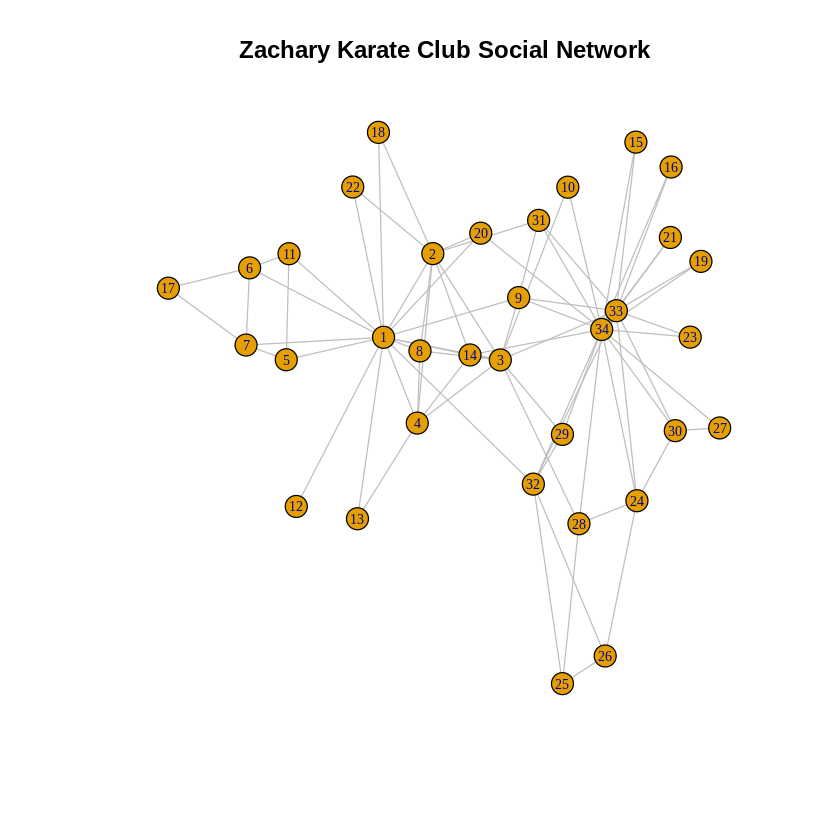

In [17]:
set.seed(123)

plot(
  karate,
  vertex.label = V(karate),
  vertex.size = 8,
  vertex.label.cex = 0.7,
  edge.color = "gray",
  main = "Zachary Karate Club Social Network"
)

### Visualization Based on Degree

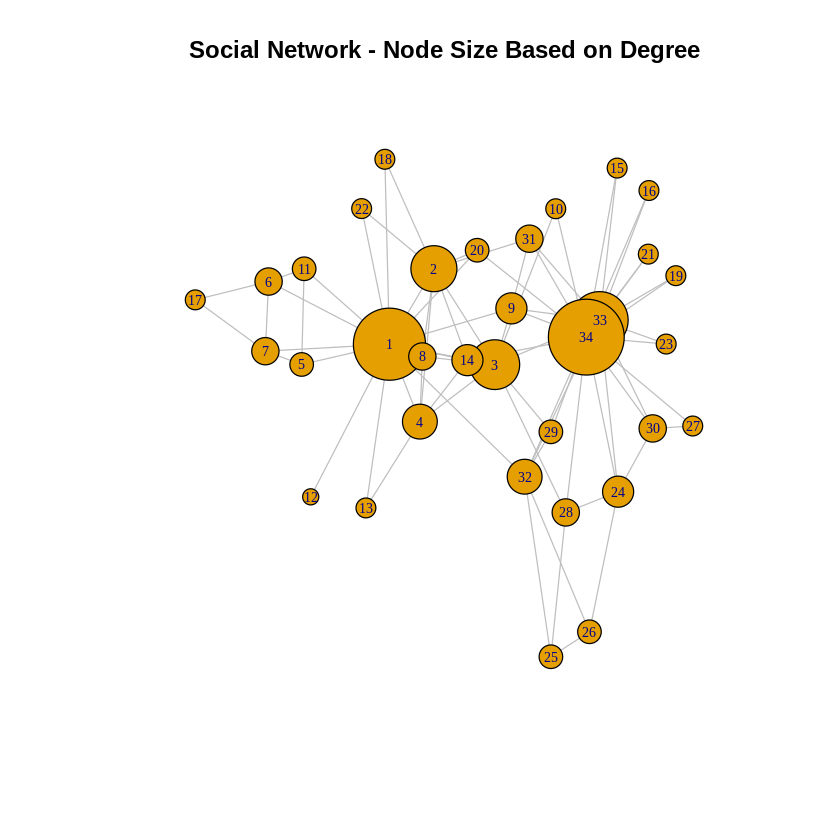

In [18]:
set.seed(123)

plot(
  karate,
  vertex.size = 5 + degree_centrality * 1.5,
  vertex.label = V(karate),
  vertex.label.cex = 0.7,
  edge.color = "gray",
  main = "Social Network - Node Size Based on Degree"
)

### Highlighting the most connected nodes

In [19]:
# Identify top 5 nodes by degree
top_degree_nodes <- names(
  head(degree_rank, 5)
)

top_degree_nodes

NULL

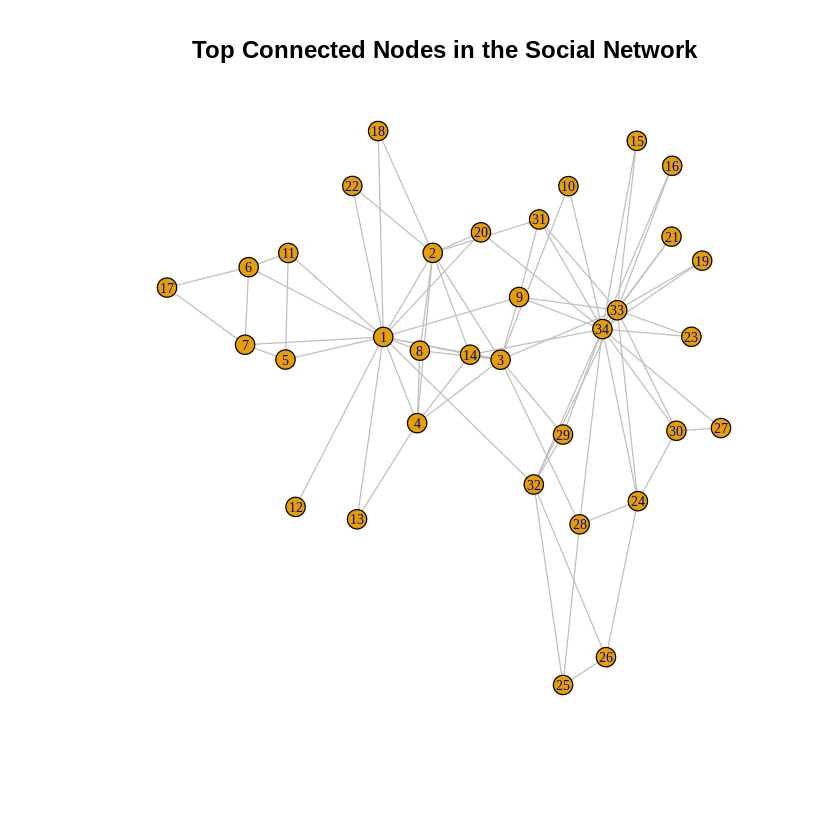

In [21]:
vertex_names <- V(karate)$name
# If vertex names are missing or empty, assign default names
if (is.null(vertex_names) || length(vertex_names) == 0) {
  vertex_names <- as.character(seq_len(vcount(karate)))
}

# Assign different sizes based on the (potentially defaulted) vertex names
node_size <- ifelse(
  vertex_names %in% top_degree_nodes,
  15,
  7
)

set.seed(123)

plot(
  karate,
  vertex.size = node_size,
  vertex.label = vertex_names,
  vertex.label.cex = 0.7,
  edge.color = "gray",
  main = "Top Connected Nodes in the Social Network"
)

### Community Detection

Community detection identifies groups of nodes that are more strongly
connected to each other than to nodes outside the group.

This can help reveal different social groups or clusters within the network.

In [22]:
# Detect communities using Louvain method
communities <- cluster_louvain(karate)

# Display community membership
membership(communities)

 [1] 1 2 2 2 1 1 1 2 3 2 1 1 2 2 3 3 1 2 3 2 3 2 3 4 4 4 3 4 4 3 3 4 3 3

### Number of Communities

In [23]:
# Number of communities
length(communities)

# Size of each community
sizes(communities)

[1] 4

Community sizes
 1  2  3  4 
 7 10 11  6 

### Community Visualization

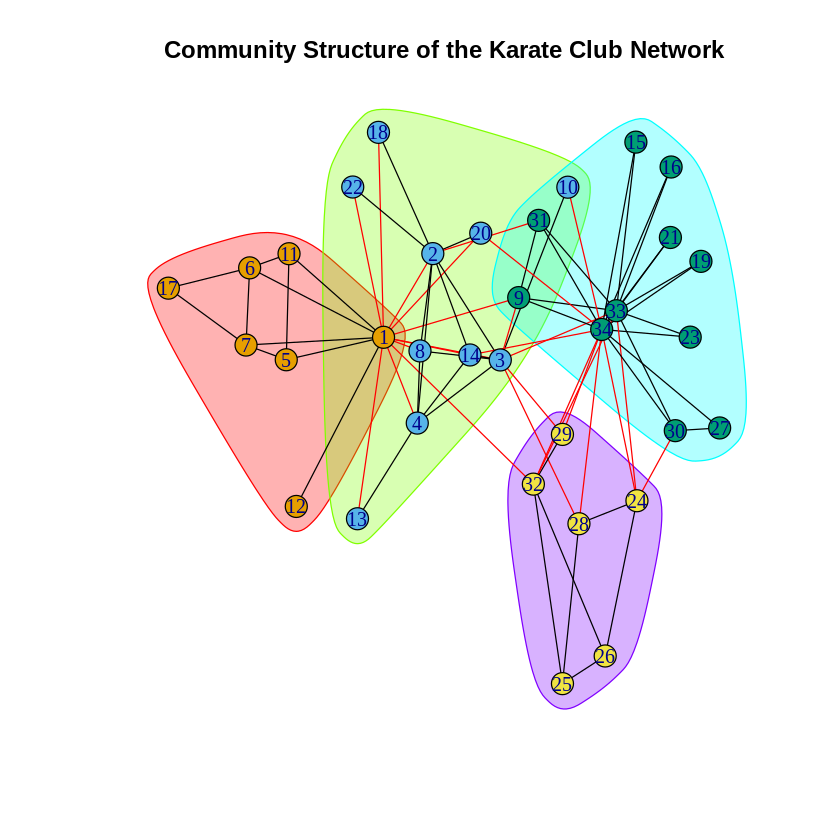

In [24]:
set.seed(123)

plot(
  communities,
  karate,
  vertex.label = V(karate),
  vertex.size = 8,
  main = "Community Structure of the Karate Club Network"
)

### Network Diameter

Network diameter represents the longest shortest-path distance between
two nodes in the network.

It provides an indication of how far apart the most distant members
are within the network.

In [25]:
diameter(karate)

[1] 5

### Avg Path Length

In [28]:
average.path.length(karate)

[1] 2.4082

### Clustering Coefficient

The clustering coefficient measures the tendency of a node's neighbors
to also be connected to each other.

A higher value indicates stronger local grouping or tightly connected
social circles.

In [29]:
transitivity(
  karate,
  type = "global"
)

[1] 0.2556818

In [34]:
cat(" NETWORK SUMMARY \n")

cat("Nodes:", vcount(karate), "\n")
cat("Edges:", ecount(karate), "\n")
cat("Density:", round(edge_density(karate), 4), "\n")
cat("Diameter:", diameter(karate), "\n")
cat("Average Path Length:",
    round(mean_distance(karate), 4), "\n")
cat("Global Clustering Coefficient:",
    round(transitivity(karate, type = "global"), 4), "\n")
cat("Communities:", length(communities), "\n")

 NETWORK SUMMARY 
Nodes: 34 
Edges: 78 
Density: 0.139 
Diameter: 5 
Average Path Length: 2.4082 
Global Clustering Coefficient: 0.2557 
Communities: 4 


### Finding the most influential node

In [39]:
# First, ensure we have a valid set of vertex names for referencing
current_vertex_names <- V(karate)$name
if (is.null(current_vertex_names) || length(current_vertex_names) == 0) {
  current_vertex_names <- as.character(seq_len(vcount(karate)))
}

# Ensure centrality vectors have these names if they don't already
# (They might be unnamed if V(karate)$name was NULL when they were created)
if (is.null(names(degree_centrality))) { names(degree_centrality) <- current_vertex_names }
if (is.null(names(betweenness_centrality))) { names(betweenness_centrality) <- current_vertex_names }
if (is.null(names(closeness_centrality))) { names(closeness_centrality) <- current_vertex_names }
if (is.null(names(eigenvector_centrality))) { names(eigenvector_centrality) <- current_vertex_names }

# Node with maximum degree
most_connected <- names(degree_centrality)[which.max(degree_centrality)]

# Node with maximum betweenness
most_between <- names(betweenness_centrality)[which.max(betweenness_centrality)]

# Node with maximum closeness
most_close <- names(closeness_centrality)[which.max(closeness_centrality)]

# Node with maximum eigenvector centrality
most_influential <- names(eigenvector_centrality)[which.max(eigenvector_centrality)]

cat("Most connected node:", most_connected, "\n")
cat("Highest betweenness node:", most_between, "\n")
cat("Highest closeness node:", most_close, "\n")
cat("Highest eigenvector centrality:", most_influential, "\n")

Most connected node: 34 
Highest betweenness node: 1 
Highest closeness node: 1 
Highest eigenvector centrality: 34 


### Find the Centrality table

In [36]:
# Top 10 nodes according to degree
top_nodes <- centrality_table[1:10, ]

top_nodes

,Node,Degree,Betweenness,Closeness,Eigenvector
,<igrph.vs>,<dbl>,<dbl>,<dbl>,<dbl>
34,34,17,0.30407498,0.5500000,1.0000000
1,1,16,0.43763528,0.5689655,0.9521324
33,33,12,0.14524711,0.5156250,0.8266589
3,3,10,0.14365681,0.5593220,0.8495542
2,2,9,0.05393669,0.4852941,0.7123351
4,4,6,0.01190927,0.4647887,0.5656143
32,32,6,0.13827561,0.5409836,0.5116565
9,9,5,0.05592683,0.5156250,0.6090684
14,14,5,0.04586340,0.5156250,0.6065744


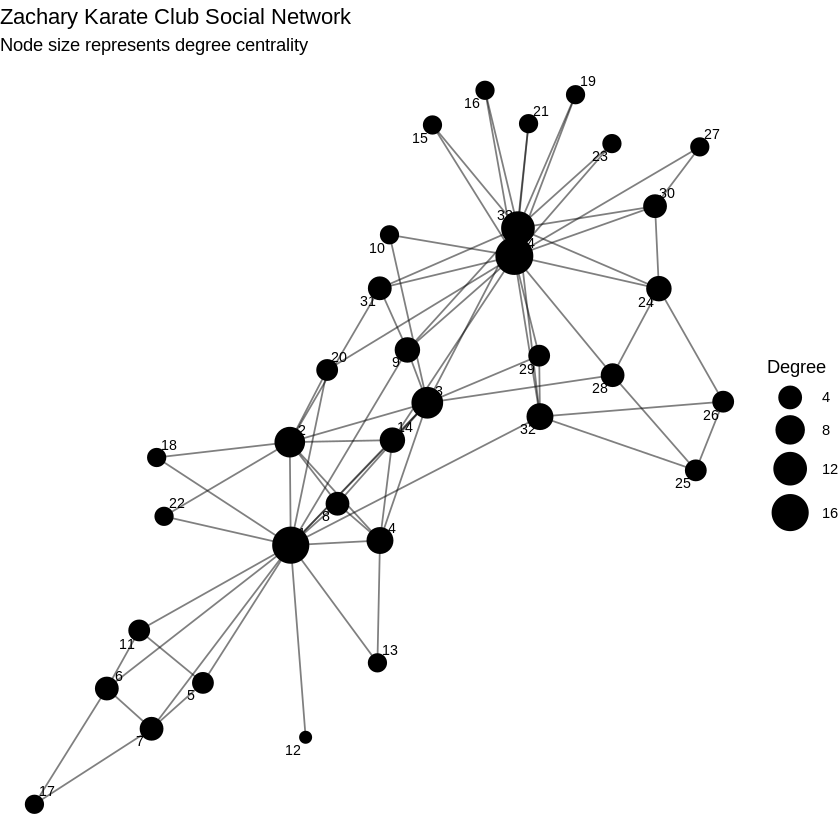

In [43]:
set.seed(123)

# Ensure karate graph vertices have names for ggraph
if (is.null(V(karate)$name) || length(V(karate)$name) == 0) {
  V(karate)$name <- as.character(seq_len(vcount(karate)))
}

ggraph(karate, layout = "fr") +
  geom_edge_link(alpha = 0.5) +
  geom_node_point(
    aes(size = degree_centrality)
  ) +
  geom_node_text(
    aes(label = .data$name),
    size = 3,
    repel = TRUE
  ) +
  scale_size_continuous(range = c(3, 10)) +
  labs(
    title = "Zachary Karate Club Social Network",
    subtitle = "Node size represents degree centrality",
    size = "Degree"
  ) +
  theme_void()

## Interpretation of Results

The Social Network Analysis was performed on the Zachary Karate Club
network using R and the `igraph` package. The network contains 34 nodes
and 78 edges, with a network density of 0.139. Since there is only one
connected component, all the members are connected directly or indirectly
through the network.

The degree centrality results show that Node 34 is the most highly
connected node with 17 connections, followed by Node 1 with 16
connections and Node 33 with 12 connections. This indicates that these
nodes have a strong presence in the network and maintain relationships
with many other members.

Betweenness centrality identifies Node 1 as the most important bridge
node, with a value of approximately 0.438. Node 34 is the second most
important according to betweenness, with a value of approximately 0.304.
This suggests that Node 1 plays an important role in connecting different
parts of the network and may have considerable importance for information
flow between members.

For closeness centrality, Node 1 has the highest value of approximately
0.569, followed by Node 3 at approximately 0.559 and Node 34 at 0.550.
This indicates that these nodes are positioned relatively close to the
other members and can reach other nodes through comparatively short paths.

Eigenvector centrality gives Node 34 the highest score of 1.000, followed
by Node 1 with approximately 0.952, Node 3 with approximately 0.850, and
Node 33 with approximately 0.827. This indicates that Node 34 is not only
highly connected but is also connected to other influential nodes.

Overall, Node 34 appears to be the most strongly connected and influential
node based on degree and eigenvector centrality, while Node 1 is the most
strategically positioned node based on betweenness and closeness. Therefore,
different centrality measures identify importance from different
perspectives.

## **Conclusion**

The Social Network Analysis experiment was successfully implemented using
R and the Zachary Karate Club dataset. The network was represented using
nodes and edges, and important network characteristics and centrality
measures were calculated.

The analysis showed that Node 34 had the highest degree and eigenvector
centrality, making it the most highly connected and influential node
according to these measures. Node 1 had the highest betweenness and
closeness centrality, indicating that it plays an important role in
connecting different parts of the network and is well positioned for
reaching other members.

The network visualization helped in understanding the relationships and
connectivity patterns between members. Overall, the experiment
demonstrates how Social Network Analysis can be used in R to identify
important nodes, understand relationships, and study the structure of
real-world networks.